In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from mpl_toolkits.mplot3d import Axes3D
from math import ceil
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [37]:
#importing data
file_path = r"cleaned_dataset_without_criticalcolumns.csv"


df = pd.read_csv(file_path)
# check data
print(df.head()) 
df.info() 

         ID  DestAct  NbTransf  TimePT  WalkingTimePT  WaitingTimePT  CostPT  \
0  10350017      2.0         4      85             23             10    12.4   
1  10350125      4.0         1      35             15              4     4.8   
2  10350125     11.0         0      11             10              0     2.2   
3  10350197      1.0         5     124             36             24    11.0   
4  10350199      4.0         4     123             21             59     9.4   

   CostCar  TimeCar  NbHousehold  ...  FreqTripHouseh  Region  distance_km  \
0     3.17       32          2.0  ...             4.0       1         30.0   
1     0.69        9          1.0  ...             3.0       1          7.0   
2     0.13        1          1.0  ...             3.0       1          1.0   
3     2.44       22          2.0  ...             3.0       1         26.0   
4     2.03       19          3.0  ...             2.0       1         22.0   

   Choice  InVehicleTime  ModeToSchool  ReportedDu

In [38]:
#DATA PROCESSING
X = df.copy()

#Make backup
org_X = X.copy()

#randomly select a subset of the dataset
#fix the randomness to be able to reproduce
#X = X.sample(n=6000, random_state=1) 


# Feature scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=df.columns)

print(X.head())

         ID   DestAct  NbTransf    TimePT  WalkingTimePT  WaitingTimePT  \
0 -1.544740 -0.612278  0.898225 -0.287879      -0.650812      -0.171418   
1 -1.544735 -0.048664 -0.508659 -0.880189      -0.963512      -0.447474   
2 -1.544735  1.923983 -0.977620 -1.164498      -1.158950      -0.631511   
3 -1.544732 -0.894084  1.367186  0.174123      -0.142674       0.472711   
4 -1.544732 -0.048664  0.898225  0.162277      -0.728987       2.083035   

     CostPT   CostCar   TimeCar  NbHousehold  ...  FreqTripHouseh    Region  \
0 -0.276850 -0.159120 -0.189372    -0.702461  ...        1.126456 -1.726308   
1 -0.591527 -0.579801 -0.666325    -1.495303  ...        0.050982 -1.726308   
2 -0.699179 -0.674794 -0.832222    -1.495303  ...        0.050982 -1.726308   
3 -0.334816 -0.282950 -0.396743    -0.702461  ...        0.050982 -1.726308   
4 -0.401064 -0.352498 -0.458954     0.090380  ...       -1.024492 -1.726308   

   distance_km   Choice  InVehicleTime  ModeToSchool  ReportedDuration  \


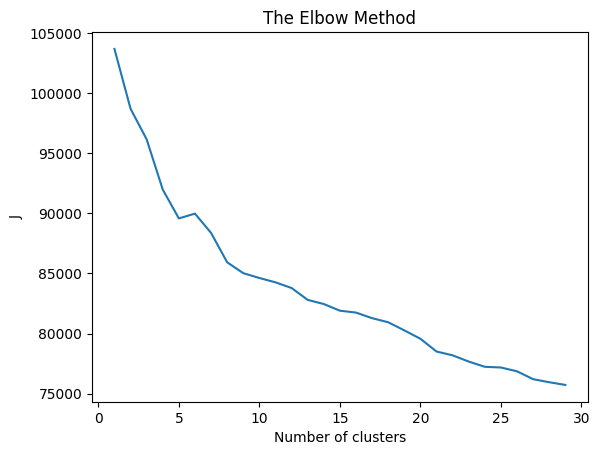

In [39]:
#decide on number of clusters using Elbow method
wcss = []
N_max = 30
for i in range(1, N_max):
    kmeans = KMeans(n_clusters=i, random_state=1, init='k-means++')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.figure()
plt.plot(range(1, N_max),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('J')
plt.show()

In [40]:
#test which amount of clusters is the better fit

range_n_clusters = range(2, 11)  # test k from 2 to 10
scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=1, init="k-means++").fit(X)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

# Best k
best_k = range_n_clusters[scores.index(max(scores))]
print("Best k:", best_k)

k=2, Silhouette Score=0.1032
k=3, Silhouette Score=0.0412
k=4, Silhouette Score=0.0415
k=5, Silhouette Score=0.0422
k=6, Silhouette Score=0.0416
k=7, Silhouette Score=0.0406
k=8, Silhouette Score=0.0307
k=9, Silhouette Score=0.0275
k=10, Silhouette Score=0.0311
Best k: 2


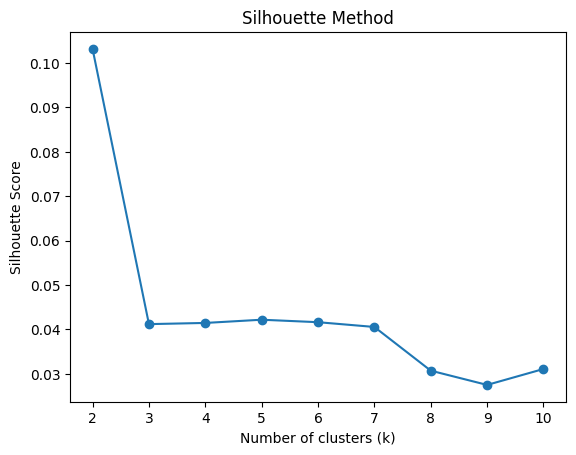

In [41]:
import matplotlib.pyplot as plt

plt.plot(range_n_clusters, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [42]:
# Implement kmeans algorithm with 2 to 4 clusters based on the outcome of the elbow method and silhouette score
kmeans_2 = KMeans(n_clusters=2, random_state=1, init="k-means++").fit(X)
kmeans_3 = KMeans(n_clusters=3, random_state=1, init="k-means++").fit(X)
kmeans_4 = KMeans(n_clusters=4, random_state=1, init="k-means++").fit(X)

# Make copy
data_cluster = org_X.copy()

# Add cluster tables
data_cluster['Cluster_2']= kmeans_2.labels_
data_cluster['Cluster_3']= kmeans_3.labels_
data_cluster['Cluster_4']= kmeans_4.labels_

print(data_cluster.head())


         ID  DestAct  NbTransf  TimePT  WalkingTimePT  WaitingTimePT  CostPT  \
0  10350017      2.0         4      85             23             10    12.4   
1  10350125      4.0         1      35             15              4     4.8   
2  10350125     11.0         0      11             10              0     2.2   
3  10350197      1.0         5     124             36             24    11.0   
4  10350199      4.0         4     123             21             59     9.4   

   CostCar  TimeCar  NbHousehold  ...  Choice  InVehicleTime  ModeToSchool  \
0     3.17       32          2.0  ...     1.0           52.0           3.0   
1     0.69        9          1.0  ...     1.0           16.0           4.0   
2     0.13        1          1.0  ...     1.0            1.0           4.0   
3     2.44       22          2.0  ...     1.0           64.0           1.0   
4     2.03       19          3.0  ...     1.0           43.0           5.0   

   ReportedDuration  CoderegionCAR   age    Weight

In [43]:
# Dataset per cluster
df_2 = data_cluster[['ID', 'Cluster_2']].copy()
df_3 = data_cluster[['ID', 'Cluster_3']].copy()
df_4 = data_cluster[['ID', 'Cluster_4']].copy()

# Saving as csv
df_2.to_csv("clusters_k2.csv", index=False)
df_3.to_csv("clusters_k3.csv", index=False)
df_4.to_csv("clusters_k4.csv", index=False)

In [44]:
data_cluster['Cluster_2'].value_counts()


Cluster_2
0    754
1    132
Name: count, dtype: int64

In [45]:
data_cluster['Cluster_3'].value_counts()


Cluster_3
0    361
1    322
2    203
Name: count, dtype: int64

In [46]:
data_cluster['Cluster_4'].value_counts()

Cluster_4
3    365
0    226
2    190
1    105
Name: count, dtype: int64

In [47]:
groups = {
    "Socio-demographic": [
        'ID', 'age', 'Gender', 'Education', 'BirthYear', 'LangCode', 
        'Mothertongue', 'FamilSitu', 'NbHousehold', 'NbChild', 'Income', 
        'OccupStat', 'SocioProfCat', 'NbComp', 'NbTV', 'Internet', 
        'NewsPaperSubs', 'NbCellPhones', 'NbSmartPhone', 'HouseType', 
        'OwnHouse', 'NbRoomsHouse', 'YearsInHouse'
    ],
    "Vehicle": [
        'NbCar', 'NbMoto', 'NbBicy', 'NbBicyChild', 'CarAvail'
    ],
    "Subscriptions": [
        'HalfFareST', 'LineRelST', 'GenAbST', 'AreaRelST', 'OtherST'
    ],
    "Spatial": [
        'UrbRur', 'TypeCommune', 'ClassifCodeLine', 'Region', 'frequency'
    ],
    "Trip": [
        'Choice', 'TimePT', 'TimeCar', 'InVehicleTime', 'WalkingTimePT', 
        'WaitingTimePT', 'ReportedDuration', 'distance_km', 'NbTransf', 
        'CostPT', 'MarginalCostPT', 'CostCarCHF', 'CostCar'
    ],
    "History": [
        'TripPurpose', 'DestAct', 'NbTrajects', 'FreqTripHouseh', 
        'ModeToSchool', 'ResidChild', 'FreqCarPar', 'FreqTrainPar', 
        'FreqOthPar'
    ],
    "Attitudes": [
        'Envir01', 'Envir02', 'Envir03', 'Envir04', 'Envir05', 'Envir06',
        
        'Mobil01', 'Mobil02', 'Mobil03', 'Mobil04', 'Mobil05', 'Mobil06', 
        'Mobil07', 'Mobil08', 'Mobil09', 'Mobil10', 'Mobil11', 'Mobil12', 
        'Mobil13', 'Mobil14', 'Mobil15', 'Mobil16', 'Mobil17', 'Mobil18', 
        'Mobil19', 'Mobil20', 'Mobil21', 'Mobil22', 'Mobil23', 'Mobil24', 
        'Mobil25', 'Mobil26', 'Mobil27',
        
        'ResidCh01', 'ResidCh02', 'ResidCh03', 'ResidCh04', 'ResidCh05', 
        'ResidCh06', 'ResidCh07',
        
        'LifSty01', 'LifSty02', 'LifSty03', 'LifSty04', 'LifSty05', 
        'LifSty06', 'LifSty07', 'LifSty08', 'LifSty09', 'LifSty10', 
        'LifSty11', 'LifSty12', 'LifSty13', 'LifSty14'
    ]
}

In [48]:
def get_defining_features(scaled_df, cluster_labels, top_n=5):
    # LAbeling scaled data
    temp_df = scaled_df.copy()
    temp_df['Cluster'] = cluster_labels
    
    # Calculate average
    cluster_profiles = temp_df.groupby('Cluster').mean()
    
    defining_vars = {}
    
    for cluster in cluster_profiles.index:
        # Look ad absolute deviation
        top_features = cluster_profiles.loc[cluster].abs().sort_values(ascending=False).head(top_n)
        
        actual_values = cluster_profiles.loc[cluster, top_features.index]
        defining_vars[cluster] = actual_values
        
    return defining_vars

# Analyse for k=2, 3 en 4
for k in [2, 3, 4]:
    print(f"\n--- TOP 5 DETERMINING VARIABLES FOR K={k} ---")
    labels = data_cluster[f'Cluster_{k}']
    top_vars = get_defining_features(X, labels) # X is je geschaalde DataFrame
    
    for cluster, vars in top_vars.items():
        print(f"\nCluster {cluster}:")
        for var_name, z_score in vars.items():
            richting = "High/Argee" if z_score > 0 else "Low/Disagree"
            print(f"  - {var_name:15} (z-score: {z_score:6.2f}) -> {richting}")
    



--- TOP 5 DETERMINING VARIABLES FOR K=2 ---

Cluster 0:
  - CostCarCHF      (z-score:  -0.32) -> Low/Disagree
  - CostCar         (z-score:  -0.32) -> Low/Disagree
  - distance_km     (z-score:  -0.32) -> Low/Disagree
  - TimeCar         (z-score:  -0.31) -> Low/Disagree
  - CostPT          (z-score:  -0.31) -> Low/Disagree

Cluster 1:
  - CostCarCHF      (z-score:   1.82) -> High/Argee
  - CostCar         (z-score:   1.82) -> High/Argee
  - distance_km     (z-score:   1.81) -> High/Argee
  - TimeCar         (z-score:   1.79) -> High/Argee
  - CostPT          (z-score:   1.75) -> High/Argee

--- TOP 5 DETERMINING VARIABLES FOR K=3 ---

Cluster 0:
  - NbBicy          (z-score:   0.60) -> High/Argee
  - Mobil10         (z-score:  -0.52) -> Low/Disagree
  - NbHousehold     (z-score:   0.49) -> High/Argee
  - LangCode        (z-score:   0.49) -> High/Argee
  - CalculatedIncome (z-score:   0.47) -> High/Argee

Cluster 1:
  - NbHousehold     (z-score:  -0.72) -> Low/Disagree
  - NbBicy     

In [49]:
# Socio-demographic features
socio_demo = [
    'age', 'Gender', 'Education', 'BirthYear', 'LangCode', 
    'Mothertongue', 'FamilSitu', 'NbHousehold', 'NbChild', 'Income', 
    'OccupStat', 'SocioProfCat', 'NbComp', 'NbTV', 'Internet', 
    'NewsPaperSubs', 'NbCellPhones', 'NbSmartPhone', 'HouseType', 
    'OwnHouse', 'NbRoomsHouse', 'YearsInHouse'
]

def get_defining_features_subset(scaled_df, cluster_labels, feature_subset, top_n=3):
    
    # Selecting features
    subset_df = scaled_df[feature_subset].copy()
    
    # Add cluster label
    subset_df['Cluster'] = cluster_labels
    
    # AVG per cluster
    cluster_profiles = subset_df.groupby('Cluster').mean()
    
    defining_vars = {}
    
    for cluster in cluster_profiles.index:
        # Sort (z-score)
        top_features = (
            cluster_profiles.loc[cluster]
            .abs()
            .sort_values(ascending=False)
            .head(top_n)
        )
        
        actual_values = cluster_profiles.loc[cluster, top_features.index]
        defining_vars[cluster] = actual_values
        
    return defining_vars


# Analyse for k=2, 3 en 4
for k in [2, 3, 4]:
    print(f"\n--- TOP 3 SOCIO-DEMOGRAPHIC VARIABLES FOR K={k} ---")
    
    labels = data_cluster[f'Cluster_{k}']
    
    top_vars = get_defining_features_subset(
        X,                # scaled data
        labels, 
        socio_demo,       
        top_n=3
    )
    
    for cluster, vars in top_vars.items():
        print(f"\nCluster {cluster}:")
        
        for var_name, z_score in vars.items():
            richting = "High" if z_score > 0 else "Low"
            print(f"  - {var_name:20} (z-score: {z_score:6.2f}) -> {richting}")


--- TOP 3 SOCIO-DEMOGRAPHIC VARIABLES FOR K=2 ---

Cluster 0:
  - Education            (z-score:  -0.05) -> Low
  - Mothertongue         (z-score:   0.03) -> High
  - LangCode             (z-score:  -0.03) -> Low

Cluster 1:
  - Education            (z-score:   0.29) -> High
  - Mothertongue         (z-score:  -0.19) -> Low
  - LangCode             (z-score:   0.18) -> High

--- TOP 3 SOCIO-DEMOGRAPHIC VARIABLES FOR K=3 ---

Cluster 0:
  - NbHousehold          (z-score:   0.49) -> High
  - LangCode             (z-score:   0.49) -> High
  - Income               (z-score:   0.46) -> High

Cluster 1:
  - NbHousehold          (z-score:  -0.72) -> Low
  - BirthYear            (z-score:  -0.58) -> Low
  - age                  (z-score:   0.58) -> High

Cluster 2:
  - LangCode             (z-score:  -1.65) -> Low
  - Mothertongue         (z-score:   1.24) -> High
  - NbChild              (z-score:   0.33) -> High

--- TOP 3 SOCIO-DEMOGRAPHIC VARIABLES FOR K=4 ---

Cluster 0:
  - NbHousehold 

In [50]:
def describe_clusters_consistent(
    scaled_df, 
    original_df, 
    cluster_labels, 
    features, 
    top_n=3
):
    
    # --- SCALED ---
    scaled_subset = scaled_df[features].copy()
    scaled_subset['Cluster'] = cluster_labels
    
    scaled_profiles = scaled_subset.groupby('Cluster').mean()
    
    # --- ORIGINAL ---
    original_subset = original_df[features].copy()
    original_subset['Cluster'] = cluster_labels
    
    original_profiles = original_subset.groupby('Cluster').mean()
    overall_mean = original_subset[features].mean()
    
    for cluster in scaled_profiles.index:
        print(f"\n=== CLUSTER {cluster} ===")
        
        # 🔥 SELECTIE OP BASIS VAN Z-SCORE
        top_features = (
            scaled_profiles.loc[cluster]
            .abs()
            .sort_values(ascending=False)
            .head(top_n)
        )
        
        for feature in top_features.index:
            
            z_score = scaled_profiles.loc[cluster, feature]
            value = original_profiles.loc[cluster, feature]
            avg = overall_mean[feature]
            
            perc = ((value - avg) / avg) * 100 if avg != 0 else 0
            
            richting = "higher" if perc > 0 else "lower"
            
            print(
                f"{feature:15} | z={z_score:5.2f} | "
                f"{value:.2f} vs {avg:.2f} | {abs(perc):.1f}% {richting}"
            )

for k in [2, 3, 4]:
    print(f"\n\n######## K = {k} ########")
    
    labels = data_cluster[f'Cluster_{k}']
    
    describe_clusters_consistent(
        X,              # scaled
        org_X,          # original
        labels,
        socio_demo,
        top_n=3
    )

    #When the precantage are small the group size is probally really high 



######## K = 2 ########

=== CLUSTER 0 ===
Education       | z=-0.05 | 4.18 vs 4.27 | 2.0% lower
Mothertongue    | z= 0.03 | 1.34 vs 1.32 | 1.4% higher
LangCode        | z=-0.03 | 1.73 vs 1.75 | 0.8% lower

=== CLUSTER 1 ===
Education       | z= 0.29 | 4.77 vs 4.27 | 11.6% higher
Mothertongue    | z=-0.19 | 1.22 vs 1.32 | 7.9% lower
LangCode        | z= 0.18 | 1.83 vs 1.75 | 4.5% higher


######## K = 3 ########

=== CLUSTER 0 ===
NbHousehold     | z= 0.49 | 3.51 vs 2.89 | 21.6% higher
LangCode        | z= 0.49 | 1.96 vs 1.75 | 12.3% higher
Income          | z= 0.46 | 4.89 vs 4.31 | 13.6% higher

=== CLUSTER 1 ===
NbHousehold     | z=-0.72 | 1.98 vs 2.89 | 31.6% lower
BirthYear       | z=-0.58 | 1955.11 vs 1962.91 | 0.4% lower
age             | z= 0.58 | 54.89 vs 47.09 | 16.6% higher

=== CLUSTER 2 ===
LangCode        | z=-1.65 | 1.03 vs 1.75 | 41.1% lower
Mothertongue    | z= 1.24 | 2.01 vs 1.32 | 52.2% higher
NbChild         | z= 0.33 | 1.03 vs 0.70 | 47.8% higher


######## K = 4 

In [55]:
#check if attitudes gives better clusters
#importing data
file_path = r"cleaned_dataset_without_criticalcolumns.csv"

attitudes = ['Envir01', 'Envir05', 'Mobil01', 'Mobil04', 'Mobil08', 'Mobil13', 
             'Mobil15', 'Mobil23', 'ResidCh05', 'ResidCh07', 'LifSty02', 
             'LifSty06', 'LifSty08', 'LifSty11']


df = pd.read_csv(file_path)
attitude_data = df[attitudes]

# check data
print(attitude_data.head()) 
attitude_data.info() 

   Envir01  Envir05  Mobil01  Mobil04  Mobil08  Mobil13  Mobil15  Mobil23  \
0      3.0      5.0      5.0      5.0      1.0      5.0      5.0      5.0   
1      4.0      4.0      4.0      4.0      2.0      4.0      4.0      4.0   
2      4.0      4.0      4.0      4.0      2.0      4.0      4.0      4.0   
3      2.0      4.0      3.0      5.0      1.0      5.0      5.0      6.0   
4      4.0      5.0      2.0      4.0      1.0      5.0      3.0      4.0   

   ResidCh05  ResidCh07  LifSty02  LifSty06  LifSty08  LifSty11  
0        1.0        5.0       3.0       5.0       5.0       3.0  
1        1.0        4.0       4.0       2.0       4.0       2.0  
2        1.0        4.0       4.0       2.0       4.0       2.0  
3        1.0        5.0       2.0       3.0       1.0       4.0  
4        1.0        5.0       3.0       2.0       5.0       2.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886 entries, 0 to 885
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtyp

    Envir01   Envir05   Mobil01   Mobil04   Mobil08   Mobil13   Mobil15  \
0  0.201357  1.332626  0.757689  0.701074 -1.120024  0.696126  1.077607   
1  0.887520  0.372702 -0.092074 -0.264947 -0.290307 -0.343955  0.065136   
2  0.887520  0.372702 -0.092074 -0.264947 -0.290307 -0.343955  0.065136   
3 -0.484806  0.372702 -0.941836  0.701074 -1.120024  0.696126  1.077607   
4  0.887520  1.332626 -1.791599 -0.264947 -1.120024  0.696126 -0.947334   

    Mobil23 ResidCh05 ResidCh07  LifSty02  LifSty06  LifSty08  LifSty11  
0  0.723599 -0.636603   0.84688  0.076336  1.614504  0.813357  0.162965  
1 -0.289211 -0.636603  -0.17677  0.966258 -0.659662 -0.204488 -0.768564  
2 -0.289211 -0.636603  -0.17677  0.966258 -0.659662 -0.204488 -0.768564  
3  1.736409 -0.636603   0.84688 -0.813585  0.098393 -3.258025  1.094494  
4 -0.289211 -0.636603   0.84688  0.076336 -0.659662  0.813357 -0.768564  


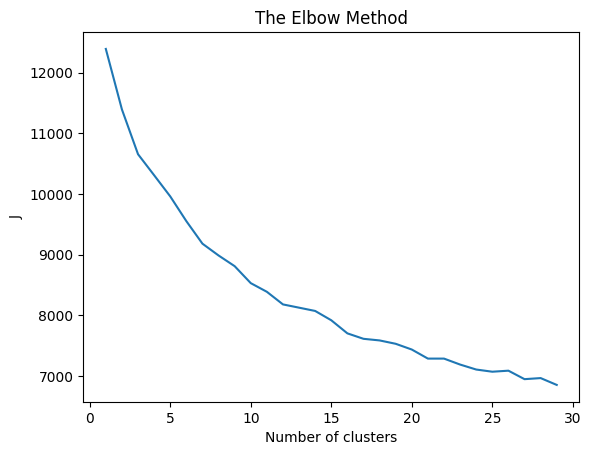

In [56]:
#DATA PROCESSING
X = attitude_data.iloc[:,:].values
X = pd.DataFrame(X)
#randomly select a subset of the dataset
#fix the randomness to be able to reproduce
#X = X.sample(n=6000, random_state=1) 

X.columns =  [attitudes] #attitudes to predict clusters
org_X_attitude = X.dropna() # to keep the version before feature scaling

# Feature scaling 
X = (X - X.mean()) / X.std()
X = X.dropna()
print(X.head()) # Prints the first 5 rows of the DataFrame
#decide on number of clusters using Elbow method


wcss = []
N_max = 30
for i in range(1, N_max):
    kmeans = KMeans(n_clusters=i, random_state=1, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.figure()
plt.plot(range(1, N_max),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('J')
plt.show()

In [57]:
#test which amount of clusters is the better fit

range_n_clusters = range(2, 11)  # test k from 2 to 10
scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=1, init="k-means++").fit(X)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

# Best k
best_k = range_n_clusters[scores.index(max(scores))]
print("Best k:", best_k)

k=2, Silhouette Score=0.0901
k=3, Silhouette Score=0.0753
k=4, Silhouette Score=0.0637
k=5, Silhouette Score=0.0625
k=6, Silhouette Score=0.0677
k=7, Silhouette Score=0.0718
k=8, Silhouette Score=0.0693
k=9, Silhouette Score=0.0718
k=10, Silhouette Score=0.0724
Best k: 2


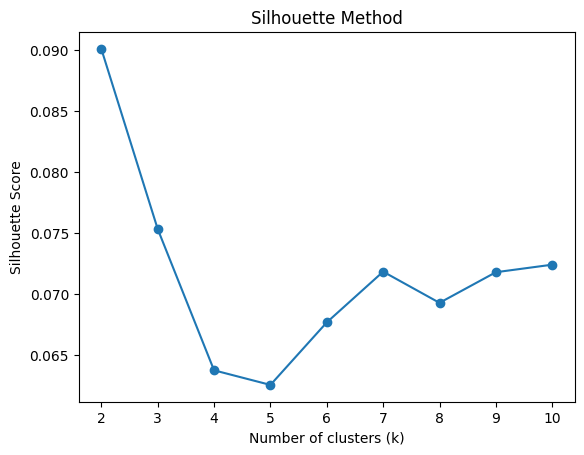

In [58]:
plt.plot(range_n_clusters, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [59]:
#implement kmeans algorithm with 4 clusters based on the outcome of the elbow method and silhouette score
kmeans_2 = KMeans(n_clusters=2, random_state=1, init="k-means++").fit(X)
kmeans_3 = KMeans(n_clusters=3, random_state=1, init="k-means++").fit(X)
kmeans_4 = KMeans(n_clusters=4, random_state=1, init="k-means++").fit(X)
#add column for clusters
#add to original before feature scaling
data_cluster_attitude = org_X_attitude
data_cluster_attitude['Cluster_2']= kmeans_2.labels_
data_cluster_attitude['Cluster_3']= kmeans_3.labels_
data_cluster_attitude['Cluster_4']= kmeans_4.labels_
data_cluster_attitude.head()

,Envir01,Envir05,Mobil01,Mobil04,Mobil08,Mobil13,Mobil15,Mobil23,ResidCh05,ResidCh07,LifSty02,LifSty06,LifSty08,LifSty11,Cluster_2,Cluster_3,Cluster_4
0,3.0,5.0,5.0,5.0,1.0,5.0,5.0,5.0,1.0,5.0,3.0,5.0,5.0,3.0,0,0,2
1,4.0,4.0,4.0,4.0,2.0,4.0,4.0,4.0,1.0,4.0,4.0,2.0,4.0,2.0,0,0,0
2,4.0,4.0,4.0,4.0,2.0,4.0,4.0,4.0,1.0,4.0,4.0,2.0,4.0,2.0,0,0,0
3,2.0,4.0,3.0,5.0,1.0,5.0,5.0,6.0,1.0,5.0,2.0,3.0,1.0,4.0,0,1,3
4,4.0,5.0,2.0,4.0,1.0,5.0,3.0,4.0,1.0,5.0,3.0,2.0,5.0,2.0,0,0,0


In [60]:
data_cluster_attitude.columns = [col[0] for col in data_cluster_attitude.columns]